<a href="https://colab.research.google.com/github/ldfha/RotemAI/blob/main/projects/pro13cnn/cnn5cifar10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CIFAR 10 dataset으로 분류기 작성 + CNN 레이어 추가
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.callbacks import EarlyStopping

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)   # (50000, 32, 32, 3) (50000, 1) (10000, 32, 32, 3) (10000, 1)
print(x_train[0])
print(y_train[0])

# 정규화
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Onehot encoding
NUM_CLASSES = 10
y_train = to_categorical(y_train, NUM_CLASSES)
y_test = to_categorical(y_test, NUM_CLASSES)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 19s 0us/step
(50000, 32, 32, 3) (50000, 1) (10000, 32, 32, 3) (10000, 1)
[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  ...
  [158 132 108]
  [152 125 102]
  [148 124 103]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  ...
  [123  88  55]
  [119  83  50]
  [122  87  57]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  ...
  [118  84  50]
  [120  84  50]
  [109  73  42]]

 ...

 [[208 170  96]
  [201 153  34]
  [198 161  26]
  ...
  [160 133  70]
  [ 56  31   7]
  [ 53  34  20]]

 [[180 139  96]
  [173 123  42]
  [186 144  30]
  ...
  [184 148  94]
  [ 97  62  34]
  [ 83  53  34]]

 [[177 144 116]
  [168 129  94]
  [179 142  87]
  ...
  [216 184 140]
  [151 118  84]
  [123  92  72]]]
[6]


In [2]:
# 모델 정의
def conv_block(x, filters):
  x = layers.Conv2D(filters=filters, kernel_size=3, padding='same', use_bias=False)(x)
  x = layers.BatchNormalization()(x)
  x = layers.ReLU()(x)
  return x

inputs = layers.Input(shape=(32, 32, 3))
# Stage 1
x = conv_block(inputs, 32)
x = conv_block(x, 32)
x = layers.MaxPooling2D()(x)
# Stage 2
x = conv_block(x, 64)
x = conv_block(x, 64)
x = layers.MaxPooling2D()(x)
# Stage 3
x = conv_block(inputs, 128)
x = conv_block(x, 128)
x = layers.MaxPooling2D()(x)

# 분류기
x = layers.GlobalAveragePooling2D()(x)  # 4차원을 2차원으로 줄여주기 때문에 Flatten 사용 안함
# CNN의 마지막 conv 출력이 (batch_size, w, w, c) 형태인데 이를 채널 평균값을 하나씩 뽑는 방식 사용
# 장점 : 파라미터 수가줄어든다. 과저갑 방지에 효과적
x = layers.Dropout(rate=0.2)(x)
x = layers.Dense(units=128, activation='relu')(x)
x = layers.Dropout(rate=0.2)(x)

outputs = layers.Dense(units=NUM_CLASSES, activation='softmax')(x)

model = Model(inputs, outputs, name='cifar10_cnn')
print(model.summary())

Model: "cifar10_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 169,738 (663.04 KB)

 Trainable params: 169,226 (661.04 KB)

 Non-trainable params: 512 (2.00 KB)

None


In [ ]:
# 모델 컴파일, 학습
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

es = EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True)

history = model.fit(
    x=x_train, y=y_train, batch_size=128, epochs=100, shuffle=True, verbose=2, callbacks=[es], validation_split=0.1
)

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0, batch_size=128)
print('test acc : %.4f'%test_loss)
print('test loss : %.4f'%test_acc)

Epoch 1/100
352/352 - 19s - 54ms/step - accuracy: 0.6536 - loss: 0.9731 - val_accuracy: 0.5342 - val_loss: 1.3007
Epoch 2/100
352/352 - 11s - 32ms/step - accuracy: 0.6599 - loss: 0.9581 - val_accuracy: 0.5448 - val_loss: 1.3142
Epoch 3/100
352/352 - 11s - 32ms/step - accuracy: 0.6600 - loss: 0.9624 - val_accuracy: 0.5764 - val_loss: 1.1931
Epoch 4/100
352/352 - 11s - 31ms/step - accuracy: 0.6652 - loss: 0.9464 - val_accuracy: 0.5786 - val_loss: 1.2248
Epoch 5/100
352/352 - 10s - 29ms/step - accuracy: 0.6683 - loss: 0.9383 - val_accuracy: 0.5838 - val_loss: 1.1639
Epoch 6/100
352/352 - 10s - 29ms/step - accuracy: 0.6683 - loss: 0.9332 - val_accuracy: 0.6350 - val_loss: 1.0635
Epoch 7/100
352/352 - 10s - 29ms/step - accuracy: 0.6741 - loss: 0.9249 - val_accuracy: 0.6386 - val_loss: 1.0441
Epoch 8/100
352/352 - 11s - 30ms/step - accuracy: 0.6762 - loss: 0.9142 - val_accuracy: 0.5348 - val_loss: 1.3781
Epoch 9/100
352/352 - 20s - 58ms/step - accuracy: 0.6758 - loss: 0.9148 - val_accuracy: 

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
예측값 : ['cat' 'automobile' 'ship' 'airplane' 'frog' 'frog' 'automobile' 'deer'
 'cat' 'automobile']
실제값 : ['cat' 'ship' 'ship' 'airplane' 'frog' 'frog' 'automobile' 'frog' 'cat'
 'automobile']
분류 실패 수 : 2


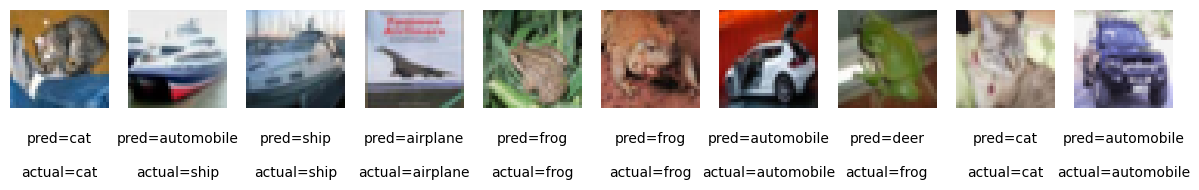

In [ ]:
CLASSES = np.array(['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'])

# 예측
pred = model.predict(x_test)
pred = CLASSES[np.argmax(pred[:10], axis=-1)]   # 0:열기준, 1:행기준, -1:행단위 뒤에서부터 처리
actual = CLASSES[np.argmax(y_test[:10], axis=-1)]

print('예측값 :', pred)
print('실제값 :', actual)
print('분류 실패 수 :', (pred != actual).sum())

# 시각화
fig = plt.figure(figsize=(15, 3))
# fig.subplots_adjust(hspace=0.4, wspace=0.4)   # subplot 사이 간격 조정

for i, idx in enumerate(range(len(x_test[:10]))):
    img = x_test[idx]
    ax = fig.add_subplot(1, len(x_test[:10]), i + 1)
    ax.axis('off')
    ax.imshow(img)

    # transAxes : 이미지 픽셀 좌표 대신에 subplot 영역 기준
    # 0.5 - 가운데 정렬, 0.0 - 왼쪽 정렬, 1.0 - 오른쪽 정렬
    ax.text(0.5, -0.35, 'pred=' + str(pred[idx]), fontsize=10, ha='center', transform=ax.transAxes)
    ax.text(0.5, -0.7, 'actual=' + str(actual[idx]), fontsize=10, ha='center', transform=ax.transAxes)

plt.show()